# RAGAS 평가 — 전·월세 팩트체커 RAG

검색+생성 파이프라인을 RAGAS로 평가한다. 제안서에서 정한 4개 지표:

| 지표 | 측정 | 필요 필드 |
|---|---|---|
| **Faithfulness** | 답변이 검색 근거에 충실한가 (환각 억제) | question, contexts, answer |
| **ResponseRelevancy** | 답변이 질문 의도에 부합하는가 | question, answer (+임베딩) |
| **LLMContextPrecisionWithoutReference** | 검색 조항이 관련성 높은 순으로 왔는가 | question, contexts, answer |
| **LLMContextRecall** | 필요한 근거를 빠짐없이 검색했는가 | question, contexts, **reference** |

준비물(.env): `DB_URL`, `OPENAI_API_KEY` / 설치: `pip install ragas`

## 0. RAGAS import 오류 우회 (필수 · 맨 먼저 실행)

`ModuleNotFoundError: langchain_community.chat_models.vertexai` 대응. 설치된 ragas 가 로드 시 ChatVertexAI 를 하드 import 하는데 현재 langchain-community 엔 그 경로가 없다. Vertex 를 쓰지 않으므로 스텁으로 통과시킨다. **ragas 를 import 하기 전에** 실행돼야 한다.

In [1]:
import importlib, sys, types
_leaf = "langchain_community.chat_models.vertexai"
try:
    importlib.import_module(_leaf)
except ModuleNotFoundError:
    import langchain_community.chat_models          # 실제 존재하는 상위 패키지
    _stub = types.ModuleType(_leaf)
    class ChatVertexAI:                             # import 통과용 스텁 (인스턴스화 안 함)
        def __init__(self, *a, **k):
            raise RuntimeError("ChatVertexAI stub — 사용되지 않음")
    _stub.ChatVertexAI = ChatVertexAI
    sys.modules[_leaf] = _stub
    print("shim 적용됨:", _leaf)


shim 적용됨: langchain_community.chat_models.vertexai


## 1. 설치 · 경로 · import

In [2]:
# !pip install -q ragas

import os, sys

def find_src_core(start=None):
    d = os.path.abspath(start or os.getcwd())
    for _ in range(6):
        cand = os.path.join(d, "src", "core")
        if os.path.isfile(os.path.join(cand, "vs_method.py")):
            return cand
        parent = os.path.dirname(d)
        if parent == d:
            break
        d = parent
    return None

SRC = find_src_core()
assert SRC, "src/core/vs_method.py 를 찾지 못했습니다."
if SRC not in sys.path:
    sys.path.insert(0, SRC)

from dotenv import load_dotenv, find_dotenv
load_dotenv(find_dotenv())
assert os.getenv("DB_URL") and os.getenv("OPENAI_API_KEY"), ".env 에 DB_URL / OPENAI_API_KEY 필요"

import vs_method
from langchain_openai import ChatOpenAI, OpenAIEmbeddings
print("src/core:", SRC)


src/core: c:\Users\playdata2\workspace\SKN30-3rd-4Team-dev\src\core


## 2. 평가할 RAG 함수 — 실제 graph 파이프라인 호출

별도 재구현 없이 `src/core/graph.py`의 `app`을 그대로 invoke 한다.
(intake 쿼리분석 → retrieve → [재작성 루프] → generate 전 경로가 평가에 반영)

- 최종 state 의 `retrieved` → RAGAS contexts, `answer` → response 로 사용해 정렬 보장
- 문항마다 **새 thread_id** 를 발급해 MemorySaver 히스토리 오염 방지
- graph 로직이 바뀌어도 노트북 수정 불필요 (파이프라인 이중 관리 제거)

In [3]:
import uuid
from langchain_core.messages import HumanMessage

import graph                      # src/core/graph.py — 실제 파이프라인

def rag_answer(question: str, stage: str = None, issues=None):
    """실제 LangGraph 앱(intake→retrieve→[rewrite]→generate)을 호출.
    반환: (answer, contexts) — contexts 는 최종 state 의 retrieved 에서 추출."""
    cfg = {"configurable": {"thread_id": f"eval-{uuid.uuid4().hex[:8]}"}}
    out = graph.app.invoke(
        {"question": question,
         "stage": stage or "post",
         "has_document": False,
         "messages": [HumanMessage(content=question)]},
        config=cfg,
    )
    contexts = [h.get("content", "") for h in (out.get("retrieved") or [])]
    if not contexts:
        # intake 가 chitchat 으로 분류하면 검색이 스킵됨 → 평가셋 문항 점검 필요
        print(f"⚠️ 검색 근거 없음 (intent={out.get('intent')}): {question[:40]}")
    return out.get("answer", ""), contexts

# 연결 확인 겸 1건 스모크 테스트
_a, _c = rag_answer("보증금을 돌려받지 못하면 어떻게 해야 하나요?", stage="post")
print("answer:", _a[:100], "...")
print("contexts:", len(_c), "건")

answer: 보증금을 돌려받지 못하면 임대인에게 반환을 요청하고, 그래도 반환하지 않을 경우에는 법원에 보증금 반환을 청구하는 소송을 제기해야 합니다. 임대인이 보증금을 반환하지 않아 어쩔 수 ...
contexts: 12 건


## 3. 평가셋 (eval_set.json 로드)

440문항(pre/post 220/220)을 `eval_set.json` 에서 불러온다. 전량을 RAGAS 로 돌리면 심판 LLM 비용이 크므로 `SAMPLE_N` 으로 **stage 균형 샘플**을 뽑는다(전체는 `SAMPLE_N=None`).

In [4]:
import json, os, random

# 노트북 위치에서 위로 올라가며 eval_set.json 탐색 (레포 어디에 두든 대응)
def _find_file(name, start=None):
    d = os.path.abspath(start or os.getcwd())
    for _ in range(6):
        for root, _dirs, files in os.walk(d):
            if name in files:
                return os.path.join(root, name)
        parent = os.path.dirname(d)
        if parent == d:
            break
        d = parent
    return None

EVAL_PATH = _find_file('eval_set.json') or 'eval_set.json'
raw = json.load(open(EVAL_PATH, encoding='utf-8'))
print('로드:', EVAL_PATH, '·', len(raw), '문항')

SAMPLE_N = 30            # stage 균형 샘플 개수 (None 이면 전체 440 — 비용 주의)
random.seed(42)

def _take(stage, n):
    pool = [r for r in raw if r['stage'] == stage]
    return pool if n is None else random.sample(pool, min(n, len(pool)))

if SAMPLE_N:
    EVAL_SET = _take('pre', SAMPLE_N // 2) + _take('post', SAMPLE_N - SAMPLE_N // 2)
else:
    EVAL_SET = raw

print('평가 대상:', len(EVAL_SET),
      '(pre', sum(r['stage']=='pre' for r in EVAL_SET),
      '/ post', sum(r['stage']=='post' for r in EVAL_SET), ')')
EVAL_SET[0]


로드: c:\Users\playdata2\Downloads\eval_set.json · 440 문항
평가 대상: 30 (pre 15 / post 15 )


{'stage': 'pre',
 'question': '계약서 특약에는 어떤 내용을 넣거나 확인해야 하나요? (2023 주택·상가건물 임대차분쟁조정사례집(한국부동산원) 근거 기준)',
 'reference': '| | 관련 판례 | 임차인이 임대인에게 임대차 목적물을 반환하는 때에는 원상회복의무가 있음(민법 제654조, 제610조, 임차인이 통상의 사용을 한 후에 임대차 목적물의 상태 악화와 가치 감소를 의미하는 통상의 손모는 임대차계약의 본질상 당연히 예상되어 있는 것으로 별도의 특약이 없는 한 통상의 손모에 대한 부분에 대해서는 임차인이 원상회복의무를 부담하지 않음.',
 'topic': '특약',
 'keywords': ['특약', '관련', '판례', '임차인이', '임대인에게', '임대차', '목적물을', '반환하는']}

## 4. 샘플 생성 (retrieve+generate 실행)

In [5]:
from ragas.dataset_schema import SingleTurnSample, EvaluationDataset

samples = []
for row in EVAL_SET:
    ans, ctx = rag_answer(row["question"], stage=row.get("stage"))
    samples.append(SingleTurnSample(
        user_input=row["question"],
        retrieved_contexts=ctx,
        response=ans,
        reference=row["reference"],
    ))

dataset = EvaluationDataset(samples=samples)
print("샘플 수:", len(samples))


c:\Users\playdata2\workspace\SKN30-3rd-4Team-dev\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


샘플 수: 30


## 5. 메트릭 · 심판 LLM 설정 후 평가

In [6]:
from ragas import evaluate
from ragas.llms import LangchainLLMWrapper
from ragas.embeddings import LangchainEmbeddingsWrapper
from ragas.metrics import Faithfulness, LLMContextPrecisionWithoutReference, LLMContextRecall
try:
    from ragas.metrics import ResponseRelevancy            # 최신
except ImportError:
    from ragas.metrics import AnswerRelevancy as ResponseRelevancy  # 구버전 폴백

# 심판(judge) LLM·임베딩 — 평가용 (토큰 비용 발생)
judge_llm = LangchainLLMWrapper(ChatOpenAI(model="gpt-4.1-mini", temperature=0))
judge_emb = LangchainEmbeddingsWrapper(
    OpenAIEmbeddings(model="text-embedding-3-small", dimensions=1024)
)

metrics = [
    Faithfulness(),
    ResponseRelevancy(),
    LLMContextPrecisionWithoutReference(),
    LLMContextRecall(),
]

result = evaluate(dataset=dataset, metrics=metrics, llm=judge_llm, embeddings=judge_emb)
result


C:\Users\playdata2\AppData\Local\Temp\ipykernel_20576\1674728691.py:4: DeprecationWarning: Importing Faithfulness from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import Faithfulness
  from ragas.metrics import Faithfulness, LLMContextPrecisionWithoutReference, LLMContextRecall
C:\Users\playdata2\AppData\Local\Temp\ipykernel_20576\1674728691.py:4: DeprecationWarning: Importing LLMContextPrecisionWithoutReference from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import LLMContextPrecisionWithoutReference
  from ragas.metrics import Faithfulness, LLMContextPrecisionWithoutReference, LLMContextRecall
C:\Users\playdata2\AppData\Local\Temp\ipykernel_20576\1674728691.py:4: DeprecationWarning: Importing LLMContextRecall from 'ragas.metrics' is deprecated and will be removed in v1.0. Please u

{'faithfulness': 0.6481, 'answer_relevancy': 0.3153, 'llm_context_precision_without_reference': 0.4789, 'context_recall': 0.2946}

## 6. 결과 표 · 평균 스코어

In [7]:
df = result.to_pandas()
df


,user_input,retrieved_contexts,response,reference,faithfulness,answer_relevancy,llm_context_precision_without_reference,context_recall
0,계약서 특약에는 어떤 내용을 넣거나 확인해야 하나요? (2023 주택·상가건물 임대...,"[2. 주택임대차표준계약서\n\n주택임대차표준계약서, | 임대차(대리인) 신분 | ...",계약서 특약에는 임대차계약의 핵심 사항과 임차인의 권리 보호를 위한 내용을 반드시 ...,| | 관련 판례 | 임차인이 임대인에게 임대차 목적물을 반환하는 때에는 원상회복의...,1.000000,0.347144,0.450000,1.00
1,계약서 특약에는 어떤 내용을 넣거나 확인해야 하나요? (민사집행법 근거 기준),[계약 시 특약사항으로 약정을 하는 것이 좋습니다. 9. 구비서류는? - 신분증 -...,계약서 특약에는 임차인의 권리 보호와 사기 위험 방지를 위해 전세자금 대출 불승인 ...,선박에 대한 경매 조문 270 일부개정 20260201 N 0270001 제270조...,0.631579,0.363362,0.500000,0.00
2,계약 전에 보증금 안전성을 판단할 때 무엇을 확인해야 하나요? (공인중개사법 시행규...,[계약금 송금 계좌 확인: 계약금 및 잔금은 반드시 등기부등본상의 임대인(소유자) ...,계약 전에 보증금 안전성을 판단할 때는 반드시 등기부등본상의 임대인 명의 계좌로 계...,최우선변제금은 「주택임대차보호법 시행령」 제10조(보증금 중 일정액의 범위 등) 및...,0.800000,0.438891,0.916667,1.00
3,계약 전에 공인중개사나 계약 상대방 확인은 어떻게 해야 하나요? (2025_주택 및...,[< 계약 체결 시 꼭 확인하세요 >\n\n【대상 및 우선체크 확인】\n- 임차인이...,계약 전에 공인중개사와 계약 상대방 확인은 반드시 등기부등본과 신분증 등 공식 서류...,제제1122조조((중중개개대대상상물물 확확인인 ․․ 설설명명서서 교교부부)) 개업공...,0.833333,0.395744,0.329870,1.00
4,계약 전에 권리관계나 등기상 위험을 어떻게 확인해야 하나요? (주택임대차보호법 시행...,"[등기부등본 확인과 법규 이해를 넘어, 전세 사기 위험을 최소화하기 위해서는 계약 ...",계약 전에 권리관계나 등기상 위험은 반드시 등기부등본을 꼼꼼히 확인해야 합니다. 주...,해당 주택 또는 그 대지의 등기기록에 기록된 권리자 중 법무부령으로 정하는 자 4.,0.777778,0.510205,0.553571,0.00
5,계약 전에 대항력과 우선변제권을 확보하려면 무엇을 준비해야 하나요? (주택도시기금법...,[우선변제권 (優先辨濟權): 대항력 요건(전입신고 + 주택 인도)을 갖추고 임대차 ...,계약 전에 대항력과 우선변제권을 확보하려면 주택을 인도받아 점유하고 주민등록상 전입...,"「가족관계의 등록 등에 관한 법률」에 따른 가족관계 등록사항, 「주민등록법」에 따른...",0.909091,0.321946,0.728869,0.00
6,계약 전에 대항력과 우선변제권을 확보하려면 무엇을 준비해야 하나요? (주민등록법 근...,[우선변제권 (優先辨濟權): 대항력 요건(전입신고 + 주택 인도)을 갖추고 임대차 ...,"계약 전에 대항력과 우선변제권을 확보하려면 주택을 인도받아 점유하고, 주소지 주민센...",제29조(열람 또는 등ㆍ초본의 교부) 열람 또는 등ㆍ초본의 교부 조문 29 타법개정...,0.777778,0.225574,0.828869,0.00
7,계약 전에 권리관계나 등기상 위험을 어떻게 확인해야 하나요? (부동산등기규칙 근거 기준),"[등기부등본 확인과 법규 이해를 넘어, 전세 사기 위험을 최소화하기 위해서는 계약 ...",계약 전에 권리관계나 등기상 위험은 반드시 등기부등본을 직접 확인하는 방법으로 점검...,가처분채권자에게 대항할 수 있는 주택임차권등기등 ② ② 가처분채권자가 제1항에 따른...,0.750000,0.482736,0.515909,0.00
8,계약서 특약에는 어떤 내용을 넣거나 확인해야 하나요? (2025_주택 및 상가건물 ...,[계약 시 특약사항으로 약정을 하는 것이 좋습니다. 9. 구비서류는? - 신분증 -...,계약서 특약에는 임차인의 권리를 강화하고 사기 위험을 줄이기 위한 내용을 반드시 서...,제2장 주택임대차 상담사례 묵시적으로 갱신되었으나 계약갱신요구에 의한 계약서를 작성...,0.750000,0.320023,0.402778,0.50
9,계약 전에 보증금 안전성을 판단할 때 무엇을 확인해야 하나요? (민사집행법 근거 기준),[등기부등본 확인 외에도 초보 세입자들은 자신을 보호하기 위한 다층적인 안전망을 구...,계약 전에 보증금 안전성을 판단할 때는 임차주택에 가압류 등 권리 제한이 있는지 반...,생계비계좌에 1월간 입금된 금액 제246조의2(생계비계좌) 생계비계좌 000000 ...,0.555556,0.471308,0.154762,0.00


In [8]:
# 지표별 평균 (0~1, 높을수록 좋음)
means = df.select_dtypes("number").mean().round(3)
print("=== RAGAS 평균 ===")
for k, v in means.items():
    print(f"  {k:42s} {v}")
means


=== RAGAS 평균 ===
  faithfulness                               0.648
  answer_relevancy                           0.315
  llm_context_precision_without_reference    0.479
  context_recall                             0.295


faithfulness                               0.648
answer_relevancy                           0.315
llm_context_precision_without_reference    0.479
context_recall                             0.295
dtype: float64

## 7. 시각화 · 저조 문항 확인

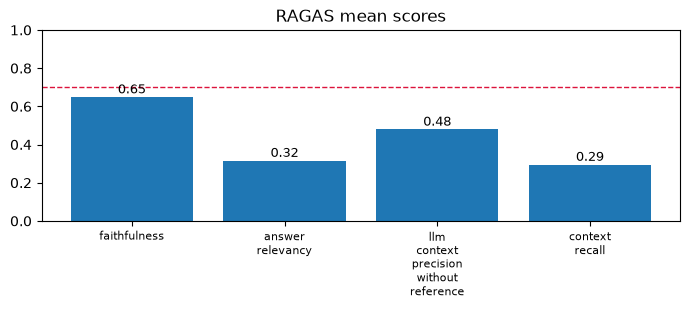

[faithfulness] 최저 0.25 → Q: 계약 후 분쟁이 생기면 어떤 절차나 기관을 활용할 수 있나요? (주민등록
[answer_relevancy] 최저 0.00 → Q: 계약 전에 공인중개사나 계약 상대방 확인은 어떻게 해야 하나요? (전세 
[llm_context_precision_without_reference] 최저 0.00 → Q: 계약 후 분쟁이 생기면 어떤 절차나 기관을 활용할 수 있나요? (주민등록
[context_recall] 최저 0.00 → Q: 계약서 특약에는 어떤 내용을 넣거나 확인해야 하나요? (민사집행법 근거 


In [9]:
import matplotlib.pyplot as plt

metric_cols = list(df.select_dtypes("number").columns)
fig, ax = plt.subplots(figsize=(7, 3.2))
ax.bar(range(len(metric_cols)), [df[c].mean() for c in metric_cols])
ax.set_xticks(range(len(metric_cols)))
ax.set_xticklabels([c.replace("_", "\n") for c in metric_cols], fontsize=8)
ax.set_ylim(0, 1)
ax.axhline(0.7, ls="--", c="crimson", lw=1)   # 참고선 0.7
ax.set_title("RAGAS mean scores")
for i, c in enumerate(metric_cols):
    ax.text(i, df[c].mean() + 0.02, f"{df[c].mean():.2f}", ha="center", fontsize=9)
plt.tight_layout(); plt.show()

# 지표별 최저 문항 (개선 대상)
for c in metric_cols:
    i = df[c].idxmin()
    print(f"[{c}] 최저 {df[c][i]:.2f} → Q: {df['user_input'][i][:40]}")


## 해석 가이드

- **Faithfulness** 낮음 → 답변이 근거를 벗어남(환각). 생성 프롬프트를 근거 기반으로 더 조이거나 verify 강화.
- **ResponseRelevancy** 낮음 → 질문 의도와 답이 어긋남. 질의 분석/쿼리 재작성 점검.
- **ContextPrecision** 낮음 → 관련 없는 조항이 상위에 섞임. 메타필터(stage·issue) 강화, k 축소.
- **ContextRecall** 낮음 → 필요한 근거를 못 찾음. 청킹·임베딩·적재량, min_score·k 조정.

참고: text-embedding-3-small + 소규모 코퍼스에선 Context 지표가 0.3~0.6대로 낮게 나오는 게 흔하다.
문항 수를 늘리고(20~50), reference 품질을 높일수록 수치가 안정된다.